# 1. Project Overview

**Project:** Vehicle Insurance Claim Validator — Master's Project (Queen's University)

**Phase:** Vehicle Damage Detection — the **Vision Module** described in the project proposal (Section V-B.1).

> *"Processes vehicle images to detect visible damage and identify affected vehicle parts. The output includes damage type, location, affected part, localization information, and confidence scores. An optional segmentation stage may refine damage boundaries when necessary."*

This notebook implements the damage-detection half of the Vision Module using **YOLOv11** (Ultralytics), fine-tuned on the **CarDD** dataset — one of the two primary vision datasets named in the proposal (Section V-E.1), alongside VehiDE.

Scope of this notebook:
- Damage **type** and **location** detection (bounding boxes) via YOLOv11 transfer learning — evaluated with **mAP@0.5**, matching the proposal's evaluation plan (Section VI).
- A rule-based **damage-severity** proxy (minor / moderate / severe), since CarDD does not ship severity labels natively — flagged clearly as a proxy requiring human calibration, following the same calibration pattern used in the Image Validation phase.
- Structured per-image JSON output (damage type, bbox, confidence, severity) ready for the Cross-Modal Consistency Layer (proposal Fig. 3).
- Inference on the images that passed the **Image Validation** phase (`final_images_for_damage_detection.csv`), so this notebook picks up exactly where that phase left off.

**Out of scope here (flagged, not silently skipped):** *affected vehicle part* identification (bumper, hood, door, etc.) requires a dedicated vehicle-parts-segmentation model (see literature review item H — SAM-based Segment Any Vehicle) that CarDD does not supervise. Every structured output below carries an explicit `affected_part: null` field with a note, rather than guessing.

**Stack:** PyTorch, Ultralytics YOLOv11, OpenCV, pandas — consistent with the implementation plan in the proposal (Section V-F.1).

# 2. Environment and GPU Setup

In [1]:
# Install required packages (skip if already installed in this environment)
!pip install -q ultralytics pycocotools scikit-learn seaborn


[notice] A new release of pip is available: 25.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import json
import shutil
import random
from pathlib import Path

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from IPython.display import display, clear_output

import torch
from ultralytics import YOLO
from pycocotools.coco import COCO
from sklearn.metrics import f1_score, classification_report

print("Torch version   :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
DEVICE = 0 if torch.cuda.is_available() else "cpu"


Torch version   : 2.11.0+cu126
CUDA available  : True
GPU             : NVIDIA A16


# 3. Dataset — CarDD

CarDD (Car Damage Detection) provides instance-level annotations for **6 damage categories**: `dent`, `scratch`, `crack`, `glass shatter`, `lamp broken`, `tire flat`, in COCO format, split into `train2017` / `val2017` / `test2017`.

Adjust `CARDD_ROOT` below to the local path of the extracted CarDD_COCO release.

In [3]:
# ==========================================
# CHECK CarDD_COCO STRUCTURE
# ==========================================

import os

CARDD_ROOT = "/home/jovyan/CarDD_coco"

print("=" * 70)
print("CarDD_COCO STRUCTURE")
print("=" * 70)

print("\nRoot contents:")

for item in sorted(os.listdir(CARDD_ROOT)):
    print(" -", item)

print("\nAnnotations:")

annotations_dir = os.path.join(
    CARDD_ROOT,
    "annotations"
)

if os.path.exists(annotations_dir):

    for item in sorted(os.listdir(annotations_dir)):
        print(" -", item)

else:
    print("❌ annotations folder not found")

CarDD_COCO STRUCTURE

Root contents:
 - annotations
 - test2017
 - train2017
 - val2017

Annotations:
 - image_info.xlsx
 - instances_test2017.json
 - instances_train2017.json
 - instances_val2017.json


In [4]:
CARDD_ROOT = "/home/jovyan/CarDD_coco"

CARDD_SPLITS = {
    "train": {
        "images": f"{CARDD_ROOT}/train2017",
        "ann": f"{CARDD_ROOT}/annotations/instances_train2017.json",
    },
    "val": {
        "images": f"{CARDD_ROOT}/val2017",
        "ann": f"{CARDD_ROOT}/annotations/instances_val2017.json",
    },
    "test": {
        "images": f"{CARDD_ROOT}/test2017",
        "ann": f"{CARDD_ROOT}/annotations/instances_test2017.json",
    },
}

for split, paths in CARDD_SPLITS.items():
    img_ok = os.path.isdir(paths["images"])
    ann_ok = os.path.isfile(paths["ann"])
    print(f"{split:5s} | images dir found: {img_ok!s:5s} | annotation file found: {ann_ok!s:5s}")

# Load categories once from the training annotation file
coco_train = COCO(CARDD_SPLITS["train"]["ann"])
CATEGORIES = coco_train.loadCats(coco_train.getCatIds())
CATEGORIES = sorted(CATEGORIES, key=lambda c: c["id"])

print("\nDamage categories in CarDD:")
for c in CATEGORIES:
    print(f"  id={c['id']:<3} name={c['name']}")


train | images dir found: True  | annotation file found: True 
val   | images dir found: True  | annotation file found: True 
test  | images dir found: True  | annotation file found: True 
loading annotations into memory...
Done (t=0.33s)
creating index...
index created!

Damage categories in CarDD:
  id=1   name=dent
  id=2   name=scratch
  id=3   name=crack
  id=4   name=glass shatter
  id=5   name=lamp broken
  id=6   name=tire flat


# 4. COCO → YOLO Format Conversion

YOLOv11 expects one `.txt` label file per image, with normalized `class x_center y_center width height` per line, plus a fixed images/labels directory layout. COCO category ids are remapped to a **contiguous 0-indexed** range in the order printed above.

In [5]:
# Contiguous 0-indexed class map, in the order returned by the COCO API
CAT_ID_TO_YOLO_ID = {c["id"]: i for i, c in enumerate(CATEGORIES)}
YOLO_ID_TO_NAME = {i: c["name"] for i, c in enumerate(CATEGORIES)}

YOLO_DATASET_ROOT = "/home/jovyan/car_damage/CarDD_YOLO"


def convert_coco_split_to_yolo(split_name, coco_ann_path, coco_img_dir, out_root):
    """
    Converts one COCO split into the YOLOv11 images/<split> + labels/<split> layout.
    Images are copied (not moved) so the original CarDD_COCO release is left untouched.
    Returns (n_images, n_boxes).
    """
    coco = COCO(coco_ann_path)

    out_img_dir = Path(out_root) / "images" / split_name
    out_lbl_dir = Path(out_root) / "labels" / split_name
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    n_images, n_boxes = 0, 0

    for img_id in tqdm(coco.getImgIds(), desc=f"Converting {split_name}"):
        img_info = coco.loadImgs(img_id)[0]
        file_name = img_info["file_name"]
        width, height = img_info["width"], img_info["height"]

        src_path = Path(coco_img_dir) / file_name
        if not src_path.exists():
            continue

        dst_path = out_img_dir / file_name
        if not dst_path.exists():
            shutil.copy2(src_path, dst_path)

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        lines = []
        for ann in anns:
            if ann.get("iscrowd", 0) == 1:
                continue
            x, y, w, h = ann["bbox"]  # COCO: top-left x, y, width, height (pixels)
            x_center = (x + w / 2) / width
            y_center = (y + h / 2) / height
            w_norm = w / width
            h_norm = h / height
            yolo_cls = CAT_ID_TO_YOLO_ID[ann["category_id"]]
            lines.append(f"{yolo_cls} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")
            n_boxes += 1

        label_path = out_lbl_dir / (Path(file_name).stem + ".txt")
        label_path.write_text("\n".join(lines))
        n_images += 1

    return n_images, n_boxes


In [6]:
RUN_COCO_TO_YOLO_CONVERSION = False  # set True once, then re-run is skipped automatically below

conversion_summary = {}

for split_name, paths in CARDD_SPLITS.items():
    out_lbl_dir = Path(YOLO_DATASET_ROOT) / "labels" / split_name
    already_converted = out_lbl_dir.exists() and any(out_lbl_dir.iterdir())

    if already_converted and not RUN_COCO_TO_YOLO_CONVERSION:
        n_images = len(list((Path(YOLO_DATASET_ROOT) / "images" / split_name).glob("*")))
        n_boxes = sum(
            len(f.read_text().strip().splitlines())
            for f in out_lbl_dir.glob("*.txt")
        )
        print(f"{split_name:5s} | already converted -> {n_images} images, {n_boxes} boxes (skipped)")
    else:
        n_images, n_boxes = convert_coco_split_to_yolo(
            split_name, paths["ann"], paths["images"], YOLO_DATASET_ROOT
        )
        print(f"{split_name:5s} | converted -> {n_images} images, {n_boxes} boxes")

    conversion_summary[split_name] = {"images": n_images, "boxes": n_boxes}

print("\nSummary:")
display(pd.DataFrame(conversion_summary).T)


train | already converted -> 2816 images, 6211 boxes (skipped)
val   | already converted -> 810 images, 1744 boxes (skipped)
test  | already converted -> 374 images, 785 boxes (skipped)

Summary:


,images,boxes
train,2816,6211
val,810,1744
test,374,785


# 5. YOLO Dataset Config (`data.yaml`)

In [7]:
data_yaml_path = f"{YOLO_DATASET_ROOT}/cardd.yaml"

data_yaml = {
    "path": YOLO_DATASET_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i: name for i, name in YOLO_ID_TO_NAME.items()},
}

with open(data_yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("Saved:", data_yaml_path)
print(yaml.safe_dump(data_yaml, sort_keys=False, allow_unicode=True))


Saved: /home/jovyan/car_damage/CarDD_YOLO/cardd.yaml
path: /home/jovyan/car_damage/CarDD_YOLO
train: images/train
val: images/val
test: images/test
names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat



# 6. Exploratory Data Analysis

,box_count
scratch,2560
dent,1806
crack,651
lamp broken,494
glass shatter,475
tire flat,225


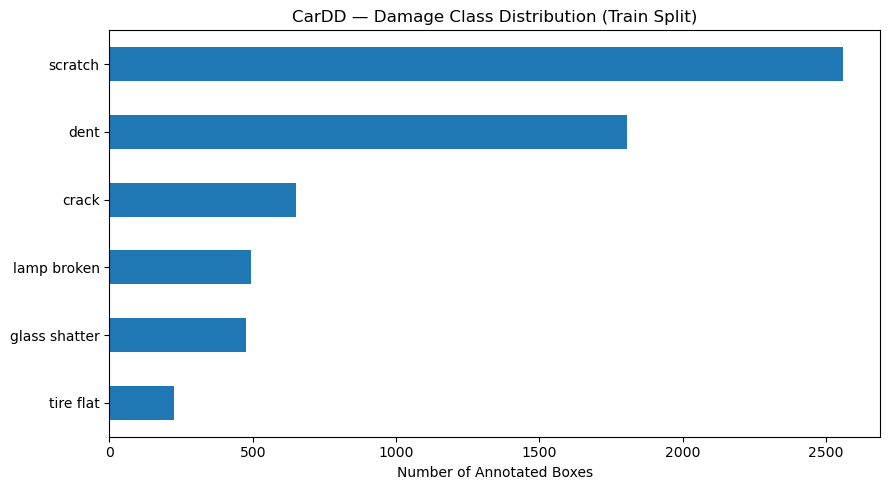

In [8]:
# Class distribution across the training split (one count per bounding box, not per image)
class_counts = {name: 0 for name in YOLO_ID_TO_NAME.values()}

train_label_dir = Path(YOLO_DATASET_ROOT) / "labels" / "train"
for label_file in train_label_dir.glob("*.txt"):
    for line in label_file.read_text().strip().splitlines():
        if not line:
            continue
        cls_id = int(line.split()[0])
        class_counts[YOLO_ID_TO_NAME[cls_id]] += 1

class_counts_df = (
    pd.Series(class_counts, name="box_count")
    .sort_values(ascending=False)
    .to_frame()
)
display(class_counts_df)

plt.figure(figsize=(9, 5))
class_counts_df["box_count"].plot(kind="barh")
plt.xlabel("Number of Annotated Boxes")
plt.title("CarDD — Damage Class Distribution (Train Split)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


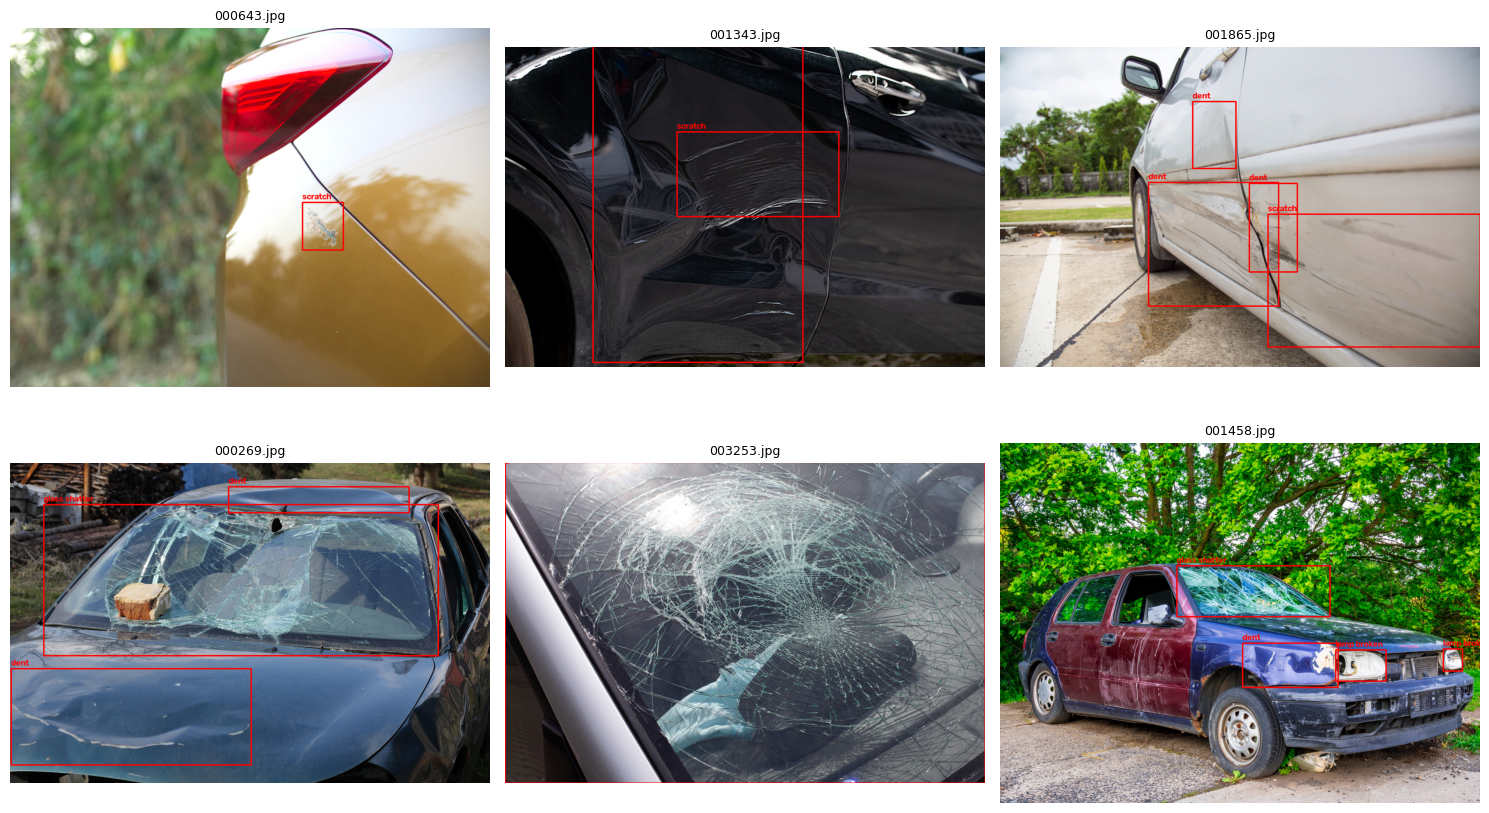

In [9]:
def draw_yolo_boxes(image_path, label_path, class_names):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    if Path(label_path).exists():
        for line in Path(label_path).read_text().strip().splitlines():
            if not line:
                continue
            cls_id, xc, yc, bw, bh = line.split()
            cls_id = int(cls_id)
            xc, yc, bw, bh = float(xc) * w, float(yc) * h, float(bw) * w, float(bh) * h
            x1, y1 = int(xc - bw / 2), int(yc - bh / 2)
            x2, y2 = int(xc + bw / 2), int(yc + bh / 2)
            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(image, class_names[cls_id], (x1, max(0, y1 - 6)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    return image


sample_images = random.sample(
    list((Path(YOLO_DATASET_ROOT) / "images" / "train").glob("*")),
    k=min(6, len(list((Path(YOLO_DATASET_ROOT) / "images" / "train").glob("*"))))
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path in zip(axes.ravel(), sample_images):
    label_path = Path(YOLO_DATASET_ROOT) / "labels" / "train" / (img_path.stem + ".txt")
    annotated = draw_yolo_boxes(img_path, label_path, YOLO_ID_TO_NAME)
    ax.imshow(annotated)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


# 7. Model Configuration — YOLOv11

`yolov11s.pt` is used as the default starting checkpoint (accuracy/speed balance for a 6-class detector on ~a few thousand images). Swap `YOLO_VARIANT` for `yolov8n.pt` (faster, lighter) or `yolov11m.pt` / `yolov11l.pt` (higher accuracy, more compute) depending on the GPU budget described in the proposal (Section X-C).

In [10]:
YOLO_VARIANT = "yolo11s.pt"

model = YOLO(YOLO_VARIANT)
print(f"Loaded pretrained checkpoint: {YOLO_VARIANT}")
print("Task:", model.task)


Loaded pretrained checkpoint: yolo11s.pt
Task: detect


# 8. Training

Transfer learning from COCO-pretrained weights onto the 6 CarDD damage classes. `RUN_TRAINING = False` by default so re-running the notebook does not silently retrain; the run is cached under `runs/detect/<RUN_NAME>` by Ultralytics and reloaded from `best.pt` if it already exists.

In [11]:
# ==========================================
# YOLO11s TRAINING
# ==========================================

RUN_NAME = "cardd_yolov11s_damage"

EPOCHS = 100
IMG_SIZE = 640
BATCH_SIZE = 16
PATIENCE = 20
SEED = 42

RUN_TRAINING = True

PROJECT_DIR = Path("/home/jovyan/runs/detect")

RUN_DIR = PROJECT_DIR / RUN_NAME

best_weights_path = Path(
    "/home/jovyan/runs/detect/"
    "runs/detect/cardd_yolov11s_damage/"
    "weights/best.pt"
)

last_weights_path = (
    RUN_DIR / "weights" / "last.pt"
)

print("=" * 70)
print("YOLO11s TRAINING CONFIGURATION")
print("=" * 70)

print("Model:", YOLO_VARIANT)
print("Dataset:", data_yaml_path)
print("Run directory:", RUN_DIR)
print("Best weights:", best_weights_path)

# ------------------------------------------
# TRAIN
# ------------------------------------------

if RUN_TRAINING:

    train_results = model.train(
        data=data_yaml_path,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        patience=PATIENCE,
        device=DEVICE,
        project=str(PROJECT_DIR),
        name=RUN_NAME,
        exist_ok=True,
        pretrained=True,
        seed=SEED,
        verbose=True,
    )

    print("\nTraining completed.")
    print("Best weights:", best_weights_path)

else:

    print("Training disabled.")

# ------------------------------------------
# LOAD BEST MODEL
# ------------------------------------------

if best_weights_path.exists():

    damage_model = YOLO(
        str(best_weights_path)
    )

    print(
        "\nLoaded best model:",
        best_weights_path
    )

else:

    print(
        "\n⚠️ best.pt not found yet."
    )

    damage_model = model

YOLO11s TRAINING CONFIGURATION
Model: yolo11s.pt
Dataset: /home/jovyan/car_damage/CarDD_YOLO/cardd.yaml
Run directory: /home/jovyan/runs/detect/cardd_yolov11s_damage
Best weights: /home/jovyan/runs/detect/runs/detect/cardd_yolov11s_damage/weights/best.pt
Ultralytics 8.4.128 🚀 Python-3.12.13 torch-2.11.0+cu126 CUDA:0 (NVIDIA A16, 14962MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/jovyan/car_damage/CarDD_YOLO/cardd.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, free


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      3.93G       1.48      2.575      1.638         72        640: 100% ━━━━━━━━━━━━ 176/176 2.2it/s 1:200.4sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 1.0it/s 25.6s0.7s
                   all        810       1744      0.277      0.337      0.289      0.162

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      5.84G      1.531      2.137      1.665         64        640: 100% ━━━━━━━━━━━━ 176/176 2.6it/s 1:070.4sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 3.7it/s 7.0s0.3s
                   all        810       1744      0.529      0.341      0.318      0.187

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      5.86G      1.566      2.147      1.689         65        

# 9. Training Curves

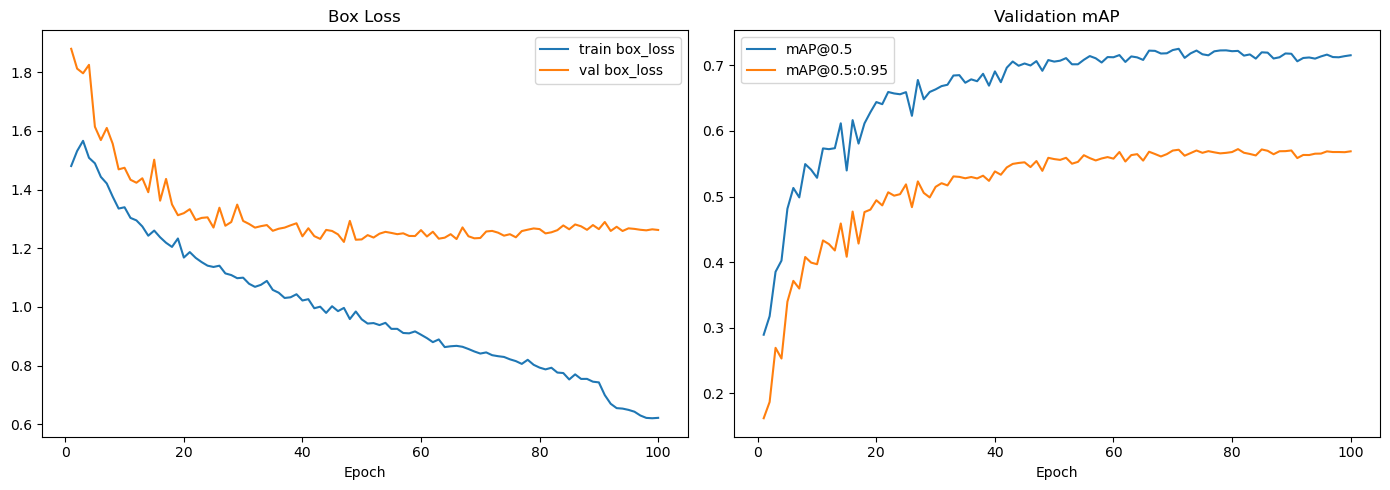

In [12]:
results_csv_path = (
    Path("/home/jovyan/runs/detect")
    / RUN_NAME
    / "results.csv"
)

if results_csv_path.exists():
    train_history = pd.read_csv(results_csv_path)
    train_history.columns = [c.strip() for c in train_history.columns]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(train_history["epoch"], train_history["train/box_loss"], label="train box_loss")
    axes[0].plot(train_history["epoch"], train_history["val/box_loss"], label="val box_loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_title("Box Loss")
    axes[0].legend()

    axes[1].plot(train_history["epoch"], train_history["metrics/mAP50(B)"], label="mAP@0.5")
    axes[1].plot(train_history["epoch"], train_history["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
    axes[1].set_xlabel("Epoch")
    axes[1].set_title("Validation mAP")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No results.csv found yet — run training first (Section 8).")


# 10. Evaluation on Test Set

Primary metric per the proposal's evaluation plan (Section VI): **mAP@0.5** for damage detection on CarDD. mAP@0.5:0.95 and per-class AP are reported alongside it for a fuller picture.

In [13]:
# ==========================================
# CARDD TEST EVALUATION
# ==========================================

eval_metrics = damage_model.val(
    data=data_yaml_path,
    split="test",
    imgsz=640,
    batch=16,
    device=DEVICE,
    verbose=True
)

print("\n" + "=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)

print("mAP@0.50     :", float(eval_metrics.box.map50))
print("mAP@0.50:0.95:", float(eval_metrics.box.map))
print("Precision    :", float(eval_metrics.box.mp))
print("Recall       :", float(eval_metrics.box.mr))

Ultralytics 8.4.128 🚀 Python-3.12.13 torch-2.11.0+cu126 CUDA:0 (NVIDIA A16, 14962MiB)
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 117.8±41.1 MB/s, size: 731.5 KB)
val: Scanning /home/jovyan/car_damage/CarDD_YOLO/labels/test.cache... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 156.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 8% ━─────────── 2/24 1.4it/s 0.9s<15.6s

Corrupt JPEG data: premature end of data segment


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 58% ━━━━━━━───── 14/24 5.6it/s 3.2s<1.8s

Corrupt JPEG data: premature end of data segment


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 4.8it/s 5.1s0.2s
                   all        374        785      0.775      0.698      0.742      0.584
                  dent        157        236      0.634      0.534      0.601      0.344
               scratch        183        307      0.663      0.557      0.584      0.318
                 crack         48         70      0.553        0.5      0.483      0.271
         glass shatter         71         71      0.899      0.972      0.982      0.923
           lamp broken         65         69      0.928      0.748      0.893      0.769
             tire flat         31         32      0.973      0.875      0.908      0.881
Speed: 1.1ms preprocess, 8.3ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /home/jovyan/runs/detect/val-2

TEST SET EVALUATION
mAP@0.50     : 0.7418375627900474
mAP@0.50:0.95: 0.584254132414727
Precision    : 0.77504500495

# 11. Qualitative Results

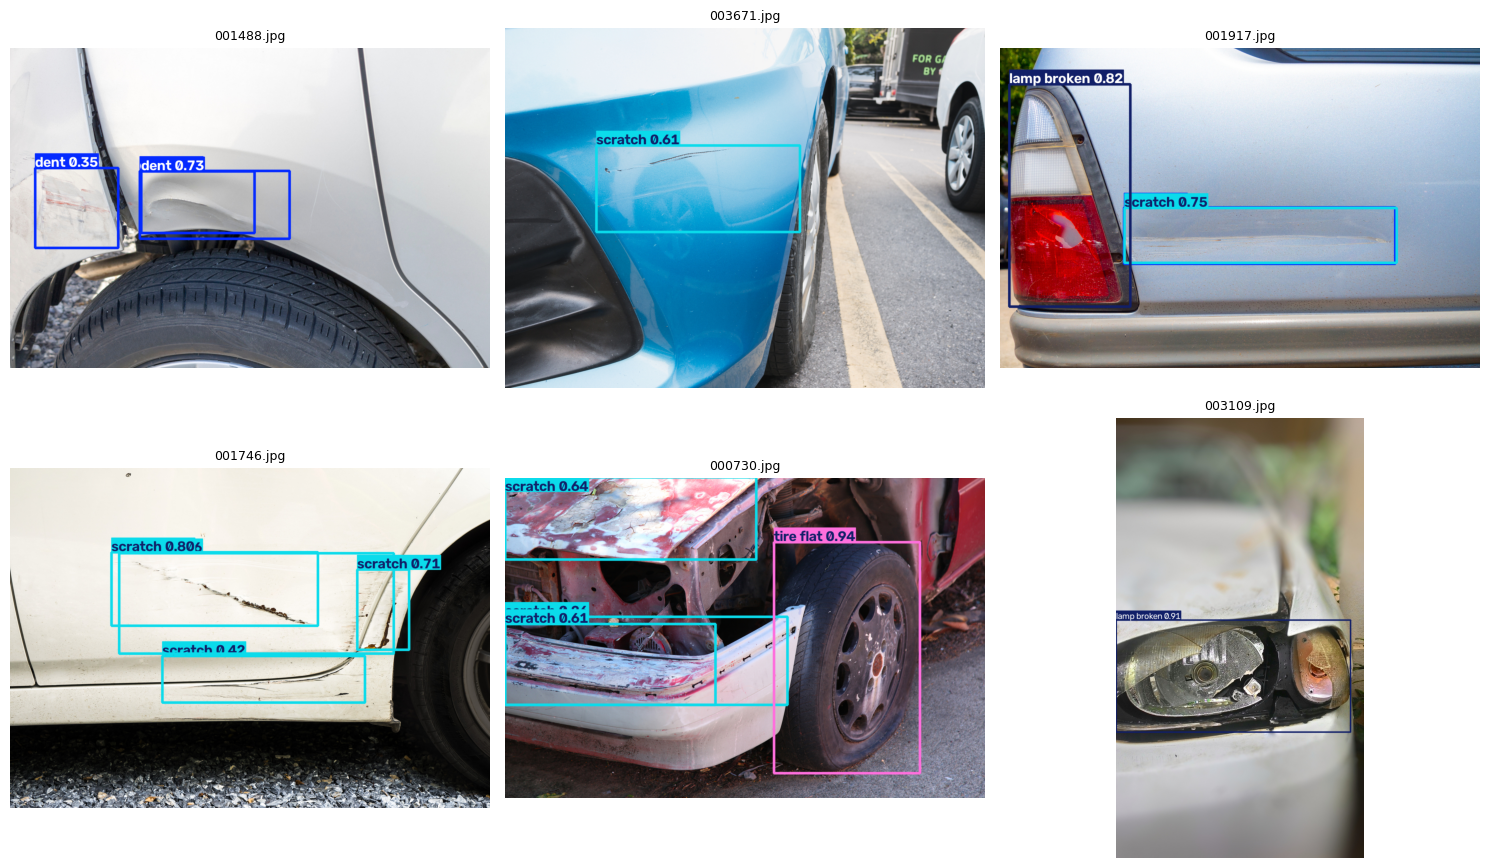

In [14]:
test_images_dir = Path(YOLO_DATASET_ROOT) / "images" / "test"
sample_test_images = random.sample(
    list(test_images_dir.glob("*")), k=min(6, len(list(test_images_dir.glob("*"))))
)

predictions = damage_model.predict(
    source=[str(p) for p in sample_test_images],
    conf=0.25,
    device=DEVICE,
    verbose=False,
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, pred in zip(axes.ravel(), predictions):
    annotated = cv2.cvtColor(pred.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(annotated)
    ax.set_title(Path(pred.path).name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


# 12. Damage Severity Classification (Heuristic Proxy)

CarDD does not provide minor / moderate / severe severity labels, so the proposal's macro-F1 severity metric (Section VI) cannot be computed against CarDD ground truth directly. This section implements a **transparent, rule-based proxy** — damage-box area relative to the full image — as a first pass, and sets up the **same human-calibration workflow** used for the image-quality thresholds in the Image Validation phase (a small manually-labeled reference set, `severity_manual_labels.csv`, checked against the rule with macro F1 once it exists).

**This proxy is not a substitute for a trained severity classifier.** It exists so the downstream Cross-Modal Consistency Layer has *something* to reason over now; refining or replacing it with a learned model is future work.

In [15]:
SEVERITY_AREA_THRESHOLDS = {
    "minor_max_ratio": 0.03,     # bbox area <= 3% of image area
    "moderate_max_ratio": 0.10,  # 3% < bbox area <= 10% of image area
    # anything above moderate_max_ratio -> severe
}


def classify_severity(bbox_xyxy, image_width, image_height, thresholds=SEVERITY_AREA_THRESHOLDS):
    x1, y1, x2, y2 = bbox_xyxy
    box_area = max(0, x2 - x1) * max(0, y2 - y1)
    image_area = image_width * image_height
    ratio = box_area / image_area if image_area > 0 else 0.0

    if ratio <= thresholds["minor_max_ratio"]:
        return "minor", ratio
    elif ratio <= thresholds["moderate_max_ratio"]:
        return "moderate", ratio
    else:
        return "severe", ratio


In [16]:
# ------------------------------------------------------------
# Human calibration scaffold (mirrors the Image Validation phase pattern):
# a small reference set of images with a human-assigned severity label,
# checked against the rule-based proxy above with macro F1.
# ------------------------------------------------------------

severity_manual_labels_file = "/home/jovyan/car_damage/severity_manual_labels.csv"

if os.path.exists(severity_manual_labels_file):
    severity_manual_df = pd.read_csv(severity_manual_labels_file)

    predicted_severity = []
    for _, row in severity_manual_df.iterrows():
        sev, _ = classify_severity(
            (row["x1"], row["y1"], row["x2"], row["y2"]),
            row["image_width"], row["image_height"],
        )
        predicted_severity.append(sev)

    severity_manual_df["predicted_severity"] = predicted_severity

    macro_f1 = f1_score(
        severity_manual_df["human_severity"], severity_manual_df["predicted_severity"],
        labels=["minor", "moderate", "severe"], average="macro",
    )
    print(f"Severity proxy vs. human labels — Macro F1: {macro_f1:.3f}")
    print(classification_report(
        severity_manual_df["human_severity"], severity_manual_df["predicted_severity"]
    ))
else:
    print("No human severity calibration set found yet.")
    print(f"Create '{severity_manual_labels_file}' with columns:")
    print("  image, x1, y1, x2, y2, image_width, image_height, human_severity")
    print("(same manual-labeling pattern as manual_labels_100.csv in the Image Validation phase)")
    print("to calibrate SEVERITY_AREA_THRESHOLDS and compute the macro-F1 metric from the proposal.")


No human severity calibration set found yet.
Create '/home/jovyan/car_damage/severity_manual_labels.csv' with columns:
  image, x1, y1, x2, y2, image_width, image_height, human_severity
(same manual-labeling pattern as manual_labels_100.csv in the Image Validation phase)
to calibrate SEVERITY_AREA_THRESHOLDS and compute the macro-F1 metric from the proposal.


# 13. Structured Per-Image Output (JSON)

One structured record per detected damage instance, in the field set the proposal's Vision Module specifies (damage type, location, affected part, confidence) plus the severity proxy from Section 12. `affected_part` is explicitly `null` — see the scope note in Section 1.

In [17]:
def run_damage_detection(image_path, conf=0.25):
    """
    Runs the trained YOLOv8 model on one image and returns a list of
    structured damage records, ready for the Cross-Modal Consistency Layer.
    """
    result = damage_model.predict(source=str(image_path), conf=conf, device=DEVICE, verbose=False)[0]
    h, w = result.orig_shape

    records = []
    for box in result.boxes:
        cls_id = int(box.cls.item())
        confidence = float(box.conf.item())
        x1, y1, x2, y2 = [float(v) for v in box.xyxy[0].tolist()]
        severity, area_ratio = classify_severity((x1, y1, x2, y2), w, h)

        records.append({
            "image": Path(image_path).name,
            "damage_type": YOLO_ID_TO_NAME[cls_id],
            "confidence": round(confidence, 4),
            "bbox_xyxy": [round(x1, 1), round(y1, 1), round(x2, 1), round(y2, 1)],
            "affected_part": None,  # requires a dedicated vehicle-parts-segmentation model (future work)
            "severity": severity,
            "severity_area_ratio": round(area_ratio, 4),
        })
    return records


# Quick demo on one sample image
demo_records = run_damage_detection(sample_test_images[0])
print(json.dumps(demo_records, indent=2))


[
  {
    "image": "001488.jpg",
    "damage_type": "dent",
    "confidence": 0.7127,
    "bbox_xyxy": [
      272.9,
      258.7,
      511.8,
      387.0
    ],
    "affected_part": null,
    "severity": "moderate",
    "severity_area_ratio": 0.0459
  },
  {
    "image": "001488.jpg",
    "damage_type": "dent",
    "confidence": 0.5939,
    "bbox_xyxy": [
      270.9,
      257.1,
      582.5,
      398.7
    ],
    "affected_part": null,
    "severity": "moderate",
    "severity_area_ratio": 0.0661
  },
  {
    "image": "001488.jpg",
    "damage_type": "dent",
    "confidence": 0.3132,
    "bbox_xyxy": [
      42.1,
      251.6,
      225.5,
      420.6
    ],
    "affected_part": null,
    "severity": "moderate",
    "severity_area_ratio": 0.0465
  }
]


# 14. Inference on Validated Images from Phase 1 (Image Validation)

Picks up `final_images_for_damage_detection.csv` from the Image Validation phase and runs damage detection on every image that finished that phase with `final_image_valid == True`.

In [18]:
validated_images_file = "/home/jovyan/car_damage/final_images_for_damage_detection.csv"

if os.path.exists(validated_images_file):
    validated_df = pd.read_csv(validated_images_file)
    damage_detection_input = validated_df[validated_df["final_image_valid"]].copy()
    print("Images ready from Image Validation phase:", len(damage_detection_input))
else:
    print(f"'{validated_images_file}' not found — run the Image Validation notebook first.")
    print("Falling back to an empty frame so this cell still runs end-to-end.")
    damage_detection_input = pd.DataFrame(columns=["image", "path"])

all_damage_records = []
for _, row in tqdm(damage_detection_input.iterrows(), total=len(damage_detection_input), desc="Damage detection"):
    all_damage_records.extend(run_damage_detection(row["path"]))

damage_results_df = pd.DataFrame(all_damage_records)

damage_results_csv = "/home/jovyan/car_damage/damage_detection_results.csv"
damage_results_json = "/home/jovyan/car_damage/damage_detection_results.json"

damage_results_df.to_csv(damage_results_csv, index=False)
with open(damage_results_json, "w") as f:
    json.dump(all_damage_records, f, indent=2)

print("=" * 70)
print("DAMAGE DETECTION — FULL RUN SUMMARY")
print("=" * 70)
print("Images processed         :", len(damage_detection_input))
print("Damage instances detected:", len(damage_results_df))
if len(damage_results_df):
    print("\nDetections per damage type:")
    print(damage_results_df["damage_type"].value_counts())
    print("\nDetections per severity bucket:")
    print(damage_results_df["severity"].value_counts())
print("\nSaved:", damage_results_csv)
print("Saved:", damage_results_json)


Images ready from Image Validation phase: 1335


Damage detection: 100%|██████████| 1335/1335 [00:25<00:00, 51.60it/s]

DAMAGE DETECTION — FULL RUN SUMMARY
Images processed         : 1335
Damage instances detected: 1924

Detections per damage type:
damage_type
scratch          582
dent             458
glass shatter    385
tire flat        230
crack            166
lamp broken      103
Name: count, dtype: int64

Detections per severity bucket:
severity
severe      1141
moderate     471
minor        312
Name: count, dtype: int64

Saved: /home/jovyan/car_damage/damage_detection_results.csv
Saved: /home/jovyan/car_damage/damage_detection_results.json


# 15. Final Results & Next Phase

**Model:** YOLOv8 (`yolov8s.pt` default), fine-tuned on CarDD (6 damage classes: dent, scratch, crack, glass shatter, lamp broken, tire flat).

**Evaluation (Section 10):** mAP@0.5 and mAP@0.5:0.95 on the CarDD test split, matching the proposal's evaluation plan (Section VI) for the vision module.

**Severity (Section 12):** a rule-based, bbox-area proxy stands in for a trained severity classifier until a human-labeled calibration set (`severity_manual_labels.csv`) is collected — flagged explicitly rather than reported as if it were validated.

**Not covered here:** *affected vehicle part* identification — every structured record carries `affected_part: null` with a pointer to the future vehicle-parts-segmentation module (literature review item H).

**Output:** `damage_detection_results.csv` / `.json` — one structured record per detected damage instance (type, bbox, confidence, severity), keyed by image, for every image that passed the Image Validation phase.

**Next phase (per the proposal's parallel-module architecture, Fig. 2):** Claim Description Module (LLM-based free-text extraction) and Document Parsing Module (OCR / layout-aware extraction) run independently on the same claims; their structured outputs and this notebook's `damage_detection_results.json` are then combined in the Cross-Modal Consistency and Reasoning Layer (Fig. 3–4).